<a href="https://colab.research.google.com/github/jess22jess/EDPII/blob/main/Prueba_de_los_Promedios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prueba de los Promedios

Es una prueba para saber si el conjunto de datos proviene de la distribución uniforme.

Ui - U(0, 1), para toda i=0, 1, 2, ..., N.

Establecemos la hipótesis:

$H_0 = \mu = 0.5$

$H_1 \neq \mu = 0.5$

In [24]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [25]:
lista = [
    0.78961, 0.05230, 0.76986, 0.12079, 0.80548, 0.82654, 0.58518, 0.98611,
    0.89898, 0.57880, 0.28269, 0.73059, 0.38618, 0.76910, 0.79982, 0.45679,
    0.58962, 0.33216, 0.69623, 0.17028, 0.29931, 0.30861, 0.57410, 0.26593,
    0.24000, 0.65559, 0.93655, 0.88809, 0.54325, 0.62400, 0.58244, 0.85853,
    0.23949, 0.53559, 0.19962, 0.65002, 0.19147, 0.40644, 0.22287, 0.07281,
    0.10699, 0.55777, 0.27738, 0.65726, 0.29453, 0.20852, 0.34488, 0.34358,
    0.67621, 0.05010, 0.70119, 0.18284, 0.68334, 0.55170, 0.21631, 0.87616,
    0.03185, 0.61168, 0.05475, 0.91512, 0.83358, 0.51781, 0.85903, 0.43308,
    0.38507, 0.90829, 0.81772, 0.36982, 0.09133, 0.41678, 0.88752, 0.33729,
    0.33381, 0.49383, 0.74579, 0.79113, 0.08128, 0.73435, 0.64183, 0.44267
]

In [26]:
promedio = np.mean(lista)

In [27]:
promedio

np.float64(0.504824875)

In [28]:
raiz = np.sqrt(len(lista))

Nuestro estadístico de prueba es:

$Z_0= \dfrac{(\bar{x}-\dfrac{1}{2})*\sqrt{N}}{\sqrt{\dfrac{1}{12}}} $


In [29]:
Z_0 = (promedio - 0.5) * raiz / np.sqrt(1/12)

In [30]:
Z_0

np.float64(0.14949328418025856)

Y Z_critico es nuestro $Z_{\dfrac{\alpha}{2}}$

In [31]:
Z_critico = stats.norm.ppf(0.975)

In [32]:
Z_critico

np.float64(1.959963984540054)

In [33]:
if abs(Z_0) < Z_critico:
  print("No se rechaza H0")
else:
  print("Se rechaza H0")

No se rechaza H0


Otra froma de obtener Z_0

In [34]:
L= lista
n = len(L)
c = 0.95

In [35]:
#utilizamos np.mean para sacar el promedio
def Promedios(L, n, c):
  M = np.mean(L)
  z_0 = ( M-0.5)*(np.sqrt(n))/np.sqrt(1/12)
# stats.norm.ppf se utiliza para sacar nuestro punto crítico, en este caso con un intervalo de confianza del 95%
  z_n = stats.norm.ppf(c)
  if z_0 < z_n:
    ent = "No existe suficiente evidencia para rechazar H0"
  else:
      ent = "Existe suficiente ev idencia para rechazar H0";
  return ent

In [36]:
Promedios(L,n,c)

'No existe suficiente evidencia para rechazar H0'

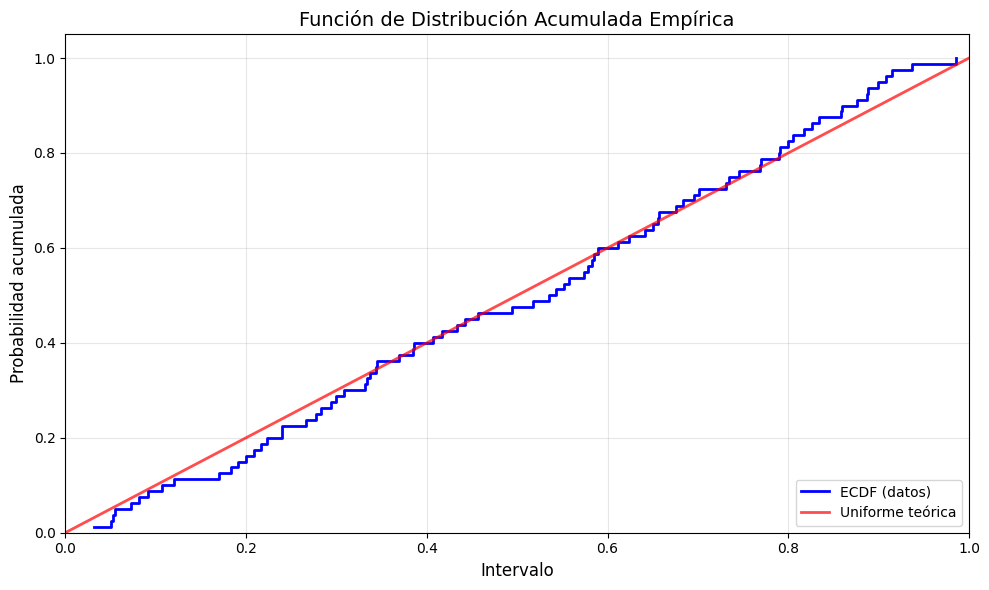

In [41]:
# Ordenar los datos
x = np.sort(lista)
y = np.arange(1, len(x) + 1) / len(x)
plt.figure(figsize=(10, 6))

plt.step(x, y, where='post', color='blue', linewidth=2, label='ECDF (datos)')

# Línea de la distribución uniforme teórica (diagonal)
plt.plot([0, 1], [0, 1], 'r-', linewidth=2, label='Uniforme teórica', alpha=0.7)

plt.title('Función de Distribución Acumulada Empírica', fontsize=14)
plt.xlabel('Intervalo', fontsize=12)
plt.ylabel('Probabilidad acumulada', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()